# Python Controle Discret

In [1]:
from Models.BallBeam import ballbeam_config
from Models.BallBeam.StateSpace import StateSpaceModel
from Models.BallBeam.TransferFunctions import TransferFunctionModel

from Simulation.simulation import TFSimulator
from Simulation.simulation import HybridSim

from Simulation.runners import *

from Metrics_Plotting.SimLog import SimLog
from Metrics_Plotting.Plotting import Plotting

from Control.DiscretePID import DiscretePID
from Control.RSTController import RSTController

import numpy as np
import control as ct
import matplotlib.pyplot as plt



In [2]:
%matplotlib inline

## Mise en place

#### Système
Ici, on spécifie l'état initial, la méthode TransferFunctionModel() donne sa fonction de tranfert qu'on met ensuite dans le simualteur de fonctions de transfert

In [3]:
X_0 = np.array([[0], [0]])
model = TransferFunctionModel(ballbeam_config)
plant_sim = TFSimulator(model.Tf_dis, 0)

Les paramètres de la simulation (Temps total et période d'échantillonage se trouvent dans le fichier Models/Ballbeam/ballbeam_config.py) mais elles peuvent etre changés dirrectement dans le notebook. Par défaut le temps de simulation T est à 3 secondes et le temps d'échantillonage à 20 ms.

In [4]:
#ballbeam_config.dt=0.1 

#### Réponse inditielle et impultionelle 
Le but est de comparer notre simualtion a celle de la librairie python

1) Réponse impulsionelle

In [5]:
## simulateur 
impulse_logger=SimLog()
impulse_logger=run_discrete_impulse_response(plant_sim,ballbeam_config,0.0,impulse_logger)
## librairie python
t = np.arange(0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib = ct.impulse_response(model.Tf_dis, t)

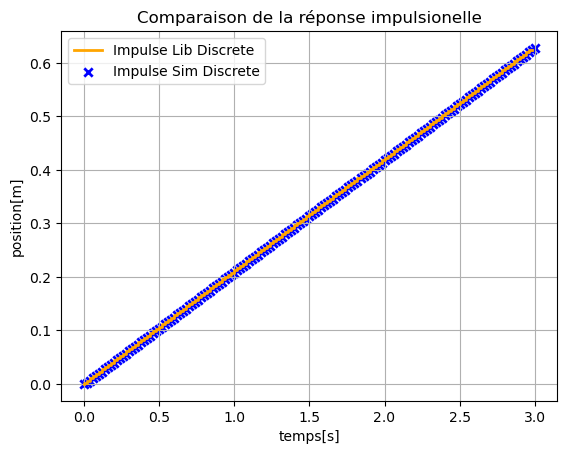

In [6]:
## affichage
fig1=plt.figure()
plt.step(
    t,
    y_lib,
    color='orange',
    linewidth=2,
    label="Impulse Lib Discrete"
)
plt.scatter(
    impulse_logger.t_hist,
    impulse_logger.y_hist,
    color='blue',
    marker='x',
    label="Impulse Sim Discrete",
    linewidth=2,
)


plt.grid()
plt.title('Comparaison de la réponse impulsionelle')
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')
#plt.savefig('Réponse_Impulsionelle_Discrete.png')
plt.show()


##### Réponse inditielle
Ici aussi, on utilise les run... pour simuler la réponse inditielle. Pour cela, on créé une nouvelle instance de SimLog

In [7]:
## simulateur 
step_logger=SimLog()
step_logger=run_discrete_step_response(plant_sim,ballbeam_config,0.0,step_logger)
## librairie python
t = np.arange(0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib = ct.step_response(model.Tf_dis, t)

In [8]:
_, y_lib = ct.step_response(model.Tf_cont, t)

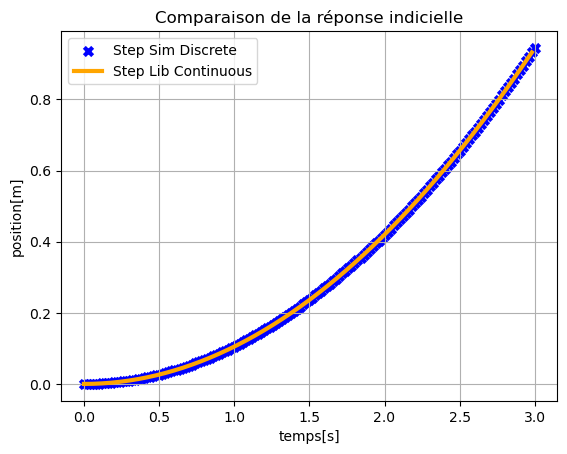

In [9]:
fig3=plt.figure()
plt.scatter(
    step_logger.t_hist,
    step_logger.y_hist,
    color='blue',
    marker='x',
    label="Step Sim Discrete",
    linewidth=3,
)

plt.plot(
    t,
    y_lib,
    color='orange',
    linestyle='-',
    linewidth=3,
    label="Step Lib Continuous"
)
plt.grid()
plt.title('Comparaison de la réponse indicielle')
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')
#plt.savefig('Réponse_Indicielle_Continue.png')
plt.show()


## Controle PID et validation


#### Mise en place du PID
On peut changer la duréé de simulation en mettant ballbeam_config.T= varaible . L'instance du PID discret est initalisé avec DiscretePID().

In [10]:
ballbeam_config.T=6

#### Modele en espace d'états (utilisé pour la simulation hybride)
Pour initailiser le simulateur continu, on lui met en entrée le ficher python contenant les matrices d'état 

In [11]:
StateSpace_Ball_Beam=StateSpaceModel(ballbeam_config)
hybrid_loop=HybridSim(StateSpace_Ball_Beam,ballbeam_config)


La fonction run_continuous_step_response prends en entrée le simulateur continu, l'état initial du système, et l'enregistreur 

In [12]:
logger_hybrid_step = SimLog()
logger_hybrid_step = run_continuous_step_response(hybrid_loop, X_0,logger_hybrid_step)

In [13]:
t = np.arange(0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib1 = ct.step_response(model.Tf_cont, t)

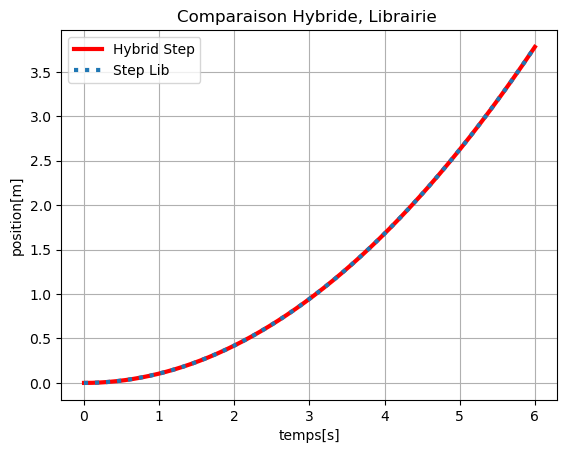

In [14]:
plt.figure()

plt.plot(
    logger_hybrid_step.t_hist,
    logger_hybrid_step.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid Step"
)
plt.plot(
    t,
    y_lib1,
    linestyle=':',
    linewidth=3,
    label="Step Lib"
)
plt.title("Comparaison Hybride, Librairie ")
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')
#plt.savefig('Réponse_Indicielle_Hybride.png')
plt.show()

La boucle fermée hybride est simulée par run_continuous_control_loop(), tout controleur qui est mis en entrée de cette fonction doit avoir la méthode setReference() et step().
Pour configurer le PID, il lui faut l'initialiser avec ses paramètres.

In [15]:
kp, ki, kd = 150,100, 100
r = 1.0
PID = DiscretePID(kp,ki,kd,ballbeam_config.dt)
#PID.reset()

In [16]:
logger_hybrid = SimLog()
logger_hybrid = run_continuous_control_loop(hybrid_loop,PID,r,X_0,logger_hybrid)


u_k- 2650.0 y_k- 0.0
u_k- 1107.0550000000003 y_k- 0.11130000000000001
u_k- -90.14782149999928 y_k- 0.38039630999999974
u_k- -821.7627170870485 y_k- 0.6922027214969994
u_k- -1109.4640119311043 y_k- 0.9657088903733432
u_k- -1059.1213021383883 y_k- 1.158103536630925
u_k- -807.3664984383018 y_k- 1.2594175996975876
u_k- -481.70829077683567 y_k- 1.2823391751400288
u_k- -177.4295418152239 y_k- 1.2511196094354344
u_k- 50.193440817191714 y_k- 1.1922162547619737
u_k- 182.45074887490205 y_k- 1.1279689838465954
u_k- 227.44092819674904 y_k- 1.0734927688982852
u_k- 208.3817737667714 y_k- 1.0362320043869842
u_k- 153.14071592171382 y_k- 1.0172757933581513
u_k- 86.70613014169028 y_k- 1.0135035268962347
u_k- 27.06707200903147 y_k- 1.0198048279689809
u_k- -15.914118166171527 y_k- 1.0308846035320576
u_k- -39.51898456280925 y_k- 1.0424328031565344
u_k- -46.071809402009094 y_k- 1.051652812466394
u_k- -40.57433997334082 y_k- 1.0572780084297313
u_k- -28.666681735173874 y_k- 1.059264066119304
u_k- -15.21653135

In [17]:
L = PID.transferFunction * model.Tf_dis
T = ct.feedback(L, 1)

t = np.arange(
    0,
    ballbeam_config.T,
    ballbeam_config.dt
)

_, y_lib = ct.step_response(T, t)

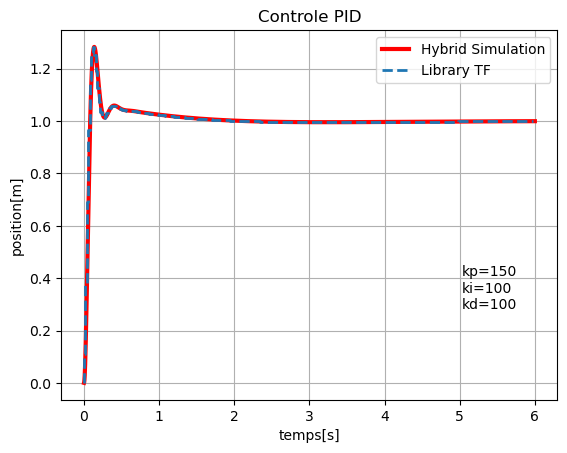

In [18]:
plt.figure()

plt.plot(
    logger_hybrid.t_hist,
    logger_hybrid.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid Simulation"
)
plt.step(t, y_lib, label="Library TF",linewidth=2,
    linestyle='--',)
plt.title("Controle PID")
text='kp='+str(kp)+'\n'+'ki='+str(ki)+'\n'+'kd='+str(kd)
plt.figtext(0.75,0.3,text)
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Réponse_Indicielle_PID.png')
plt.show()


Outil pour exporter un enregistreur sous forme de fichier CSV

In [19]:
from Utils import utils
#utils.as_csv('hybridLog',logger_hybrid)

Controle RST, les polynomes R, S et T doivent etre entrés dans RSTController() \
Ici, on a utilisé le PID discret changé en structure RST

In [20]:
rst=RSTController(PID.R,PID.S,PID.T)
logger_rst = SimLog()
logger_rst = run_continuous_control_loop(hybrid_loop,rst,r,X_0,logger_rst)

u_k- 2650.0 y_k- 0.0
u_k- 1107.0549999999998 y_k- 0.11130000000000001
u_k- -90.14782149999951 y_k- 0.38039630999999974
u_k- -821.7627170870488 y_k- 0.6922027214969994
u_k- -1109.4640119311046 y_k- 0.9657088903733432
u_k- -1059.1213021383885 y_k- 1.158103536630925
u_k- -807.3664984383031 y_k- 1.2594175996975876
u_k- -481.708290776838 y_k- 1.2823391751400288
u_k- -177.42954181522668 y_k- 1.2511196094354344
u_k- 50.19344081718856 y_k- 1.1922162547619737
u_k- 182.4507488748994 y_k- 1.1279689838465952
u_k- 227.44092819674833 y_k- 1.073492768898284
u_k- 208.38177376677203 y_k- 1.0362320043869822
u_k- 153.14071592171553 y_k- 1.0172757933581482
u_k- 86.70613014169231 y_k- 1.0135035268962305
u_k- 27.067072009032017 y_k- 1.0198048279689762
u_k- -15.914118166171562 y_k- 1.0308846035320525
u_k- -39.518984562808654 y_k- 1.0424328031565286
u_k- -46.071809402008135 y_k- 1.0516528124663878
u_k- -40.57433997333937 y_k- 1.0572780084297246
u_k- -28.666681735172006 y_k- 1.0592640661192967
u_k- -15.2165313

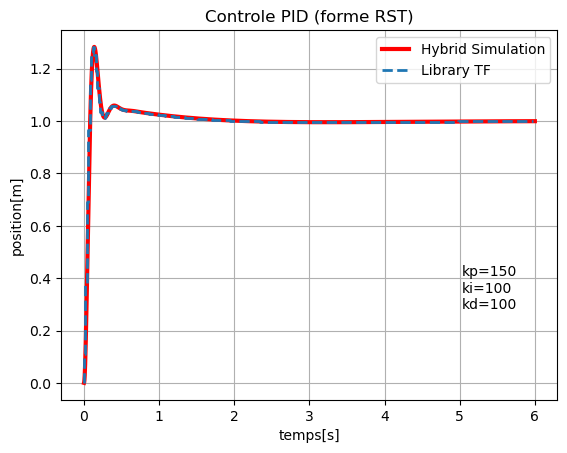

In [21]:
plt.figure()

plt.plot(
    logger_rst.t_hist,
    logger_rst.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid Simulation"
)
plt.step(t, y_lib, label="Library TF",linewidth=2,
    linestyle='--',)
plt.title("Controle PID (forme RST)")
text='kp='+str(kp)+'\n'+'ki='+str(ki)+'\n'+'kd='+str(kd)
plt.figtext(0.75,0.3,text)
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Réponse_Indicielle_PID.png')
plt.show()


In [22]:
logger_discrete_control=SimLog()
logger_discrete_control=run_discrete_control(plant_sim,rst,ballbeam_config,1.0,0,logger_discrete_control)

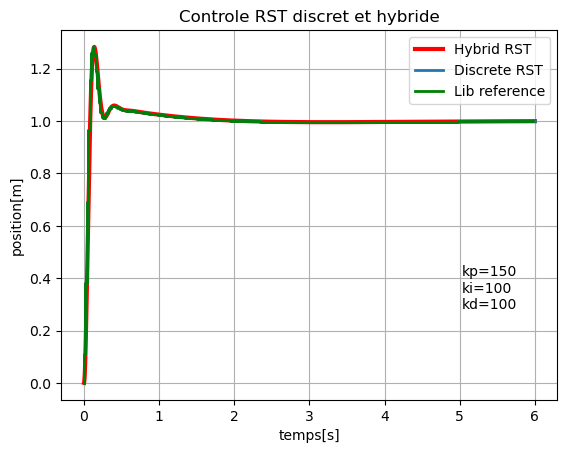

In [23]:
plt.figure()

plt.plot(
    logger_rst.t_hist,
    logger_rst.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid RST"
)
plt.step(logger_discrete_control.t_hist, logger_discrete_control.y_hist, label="Discrete RST",linewidth=2,
    linestyle='-',)
plt.step(t,y_lib,label="Lib reference",color="green",linewidth=2,
    linestyle='-',)
plt.title("Controle RST discret et hybride")
text='kp='+str(kp)+'\n'+'ki='+str(ki)+'\n'+'kd='+str(kd)
plt.figtext(0.75,0.3,text)
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Comparaision_hybride_discret_simu.png')
plt.show()


RST avec fonction de transfert en BF désirée 

In [ ]:
omega_n = 5  # Natural frequency in rad/s
zeta = 0.707  # Damping ratio (optimal balance of speed and overshoot)

# Standard second-order form: omega_n^2 / (s^2 + 2*zeta*omega_n*s + omega_n^2)
num_cl = [omega_n**2]
den_cl = [1, 2 * zeta * omega_n, omega_n**2]
G_cl_continuous = ct.tf(num_cl, den_cl)

# Discretize the desired tracking target
desired_discrete = ct.c2d(G_cl_continuous,ballbeam_config.dt, method="zoh")
print(desired_discrete)


In [25]:
R,S,T=utils.Compute_Desired_RST(desired_discrete,model.Tf_dis)


--- New Causal RST Synthesis ---
Closed-loop poles roots: [0.92941229+0.0658391j 0.92941229-0.0658391j]
Poles magnitude: [0.93174137 0.93174137]
S coefficients: [0.93174164]
R coefficients: [ 1625.19905442 -1514.27748265]
T coefficients: [56.76781182 54.15375995]
<TransferFunction>: sys[31]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

  0.002384 z^2 + 0.004659 z + 0.002274
  ------------------------------------
         z^2 - 1.859 z + 0.8681


In [26]:
rst_2=RSTController(R,S,T)
logger_rst_test = SimLog()
logger_rst_test = run_continuous_control_loop(hybrid_loop,rst_2,1.0,X_0,logger_rst_test)

u_k- 0.032545511222775526 y_k- 0.0
u_k- 0.09391660687591796 y_k- 1.3669114713565723e-06
u_k- 0.1510990558554225 y_k- 8.04523190285827e-06
u_k- 0.2043787318720281 y_k- 2.501421016907626e-05
u_k- 0.2540219947904828 y_k- 5.6913255519847165e-05
u_k- 0.30027702265191664 y_k- 0.00010806513139044353
u_k- 0.3433750527718745 y_k- 0.00018249756599362068
u_k- 0.3835315381205389 y_k- 0.0002839633877645971
u_k- 0.42094722476801116 y_k- 0.00041595928635305485
u_k- 0.45580915578277914 y_k- 0.0005817432929828317
u_k- 0.48829160660370463 y_k- 0.0007843510675957417
u_k- 0.5185569565631734 y_k- 0.0010266110742288839
u_k- 0.5467565009197521 y_k- 0.001311158720515035
u_k- 0.5730312074611971 y_k- 0.001640449532015469
u_k- 0.5975124214614602 y_k- 0.0020167714272679017
u_k- 0.6203225225170708 y_k- 0.0024422561549350863
u_k- 0.6415755365476223 y_k- 0.00291888995024937
u_k- 0.6613777060208799 y_k- 0.003448523464044372
u_k- 0.6798280212541105 y_k- 0.00403288101402725
u_k- 0.6970187154485894 y_k- 0.00467356920455

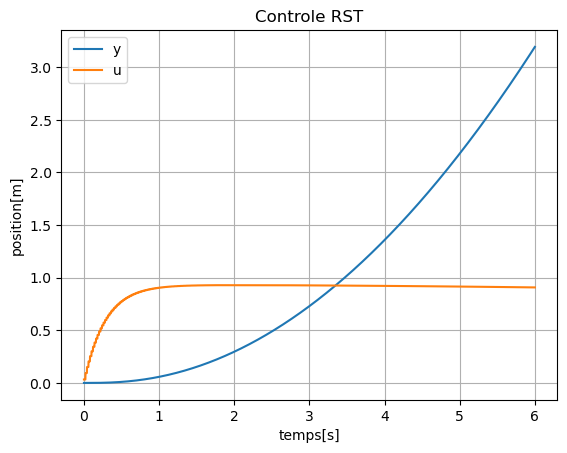

In [27]:
plt.figure()
plt.plot(logger_rst_test.t_hist, logger_rst_test.y_hist, label="y")
plt.plot(logger_rst_test.t_hist, logger_rst_test.u_hist, label="u")

plt.title("Controle RST")
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Réponse_Indicielle_PID.png')
plt.show()

In [28]:
utils.as_csv('RSTLog',logger_rst_test)